# LAB5: Sieci MLP w PyTorch dla PlantVillage

Celem notebooka jest konstrukcja i ewaluacja wielowarstwowej sieci MLP dla klasyfikacji obrazów liści z bazy PlantVillage. Notebook korzysta z danych znajdujących się w katalogu `archive (2)/plantvillage dataset/color`.

Realizowane elementy:

- klasyfikacja obrazów dla co najmniej 5 klas,
- MLP z jedną oraz dwiema warstwami ukrytymi,
- porównanie hiperparametrów: `batch_size`, optymalizator, `learning_rate`, regularyzacja, augmentacja, funkcje aktywacji,
- standardowe wizualizacje dokładnościowe,
- końcowa tabela z hiperparametrami i dokładnością,
- dodatkowy model CNN do wizualizacji filtrów splotowych.

Uwaga: czysty MLP nie posiada filtrów splotowych, ponieważ spłaszcza obraz do wektora. Dlatego wizualizacja filtrów jest pokazana na dodatkowym, małym modelu CNN.

## 1. Importy i konfiguracja

In [ ]:
from pathlib import Path
import random
import time
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

IMG_SIZE = 64
NUM_CLASSES = 5

# Ograniczenie liczby obrazów na klasę przyspiesza wiele eksperymentów MLP.

MAX_IMAGES_PER_CLASS = 600

DATA_ROOT_CANDIDATES = [
    Path("archive (2)") / "plantvillage dataset" / "color",
    Path(r"C:\Users\misie\Downloads\LAB5\archive (2)\plantvillage dataset\color"),
]

DATA_ROOT = next((p for p in DATA_ROOT_CANDIDATES if p.exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError("Nie znaleziono danych. Sprawdź katalog archive (2)/plantvillage dataset/color.")

print("DATA_ROOT:", DATA_ROOT.resolve())

Device: cpu
DATA_ROOT: C:\Users\misie\Downloads\LAB5\archive (2)\plantvillage dataset\color


## 2. Wczytanie danych i wybór klas

In [2]:
base_dataset = datasets.ImageFolder(DATA_ROOT)
all_classes = base_dataset.classes

# Wybieramy 5 klas. Można wpisać własne nazwy z listy all_classes.
SELECTED_CLASSES = all_classes[:NUM_CLASSES]

selected_old_ids = [base_dataset.class_to_idx[class_name] for class_name in SELECTED_CLASSES]
old_to_new = {old_idx: new_idx for new_idx, old_idx in enumerate(selected_old_ids)}

selected_indices = []
per_class_counter = {old_idx: 0 for old_idx in selected_old_ids}

for sample_idx, (_, old_target) in enumerate(base_dataset.samples):
    if old_target in selected_old_ids:
        if MAX_IMAGES_PER_CLASS is None or per_class_counter[old_target] < MAX_IMAGES_PER_CLASS:
            selected_indices.append(sample_idx)
            per_class_counter[old_target] += 1

targets_new = np.array([old_to_new[base_dataset.samples[i][1]] for i in selected_indices])

print("Liczba wszystkich klas:", len(all_classes))
print("Wybrane klasy:")
for i, class_name in enumerate(SELECTED_CLASSES):
    print(f"{i}: {class_name} ({sum(targets_new == i)} obrazów)")
print("Liczba wybranych obrazów:", len(selected_indices))

Liczba wszystkich klas: 38
Wybrane klasy:
0: Apple___Apple_scab (600 obrazów)
1: Apple___Black_rot (600 obrazów)
2: Apple___Cedar_apple_rust (275 obrazów)
3: Apple___healthy (600 obrazów)
4: Blueberry___healthy (600 obrazów)
Liczba wybranych obrazów: 2675


In [3]:
train_idx, temp_idx, y_train, y_temp = train_test_split(
    selected_indices,
    targets_new,
    test_size=0.30,
    random_state=SEED,
    stratify=targets_new,
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

print(f"Train: {len(train_idx)} | Validation: {len(val_idx)} | Test: {len(test_idx)}")

Train: 1872 | Validation: 401 | Test: 402


## 3. Dataset, augmentacja i DataLoader

In [4]:
class PlantVillageSubset(datasets.ImageFolder):
    def __init__(self, root, old_to_new, transform=None):
        super().__init__(root, transform=transform)
        self.old_to_new = old_to_new

    def __getitem__(self, index):
        image, old_target = super().__getitem__(index)
        return image, self.old_to_new[old_target]


def get_transforms(augment=False):
    train_steps = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
    if augment:
        train_steps += [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(20),
            transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.92, 1.08)),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
        ]
    train_steps += [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]

    eval_steps = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
    return transforms.Compose(train_steps), transforms.Compose(eval_steps)


def make_loaders(batch_size=32, augment=False):
    train_transform, eval_transform = get_transforms(augment=augment)

    train_dataset = PlantVillageSubset(DATA_ROOT, old_to_new, transform=train_transform)
    val_dataset = PlantVillageSubset(DATA_ROOT, old_to_new, transform=eval_transform)
    test_dataset = PlantVillageSubset(DATA_ROOT, old_to_new, transform=eval_transform)

    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(val_dataset, val_idx)
    test_subset = Subset(test_dataset, test_idx)

    return (
        DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0),
        DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0),
        DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=0),
    )

## 4. Wizualizacja danych

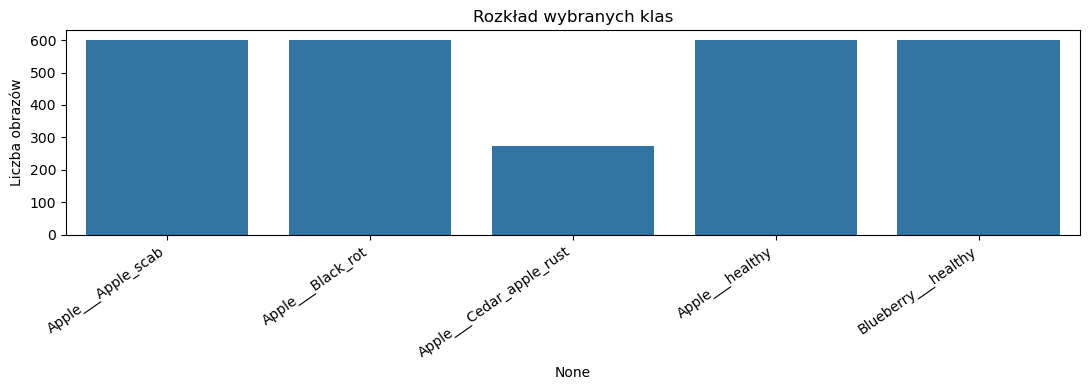

In [5]:
counts = pd.Series(targets_new).value_counts().sort_index()
counts.index = SELECTED_CLASSES

plt.figure(figsize=(11, 4))
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Liczba obrazów")
plt.title("Rozkład wybranych klas")
plt.tight_layout()
plt.show()

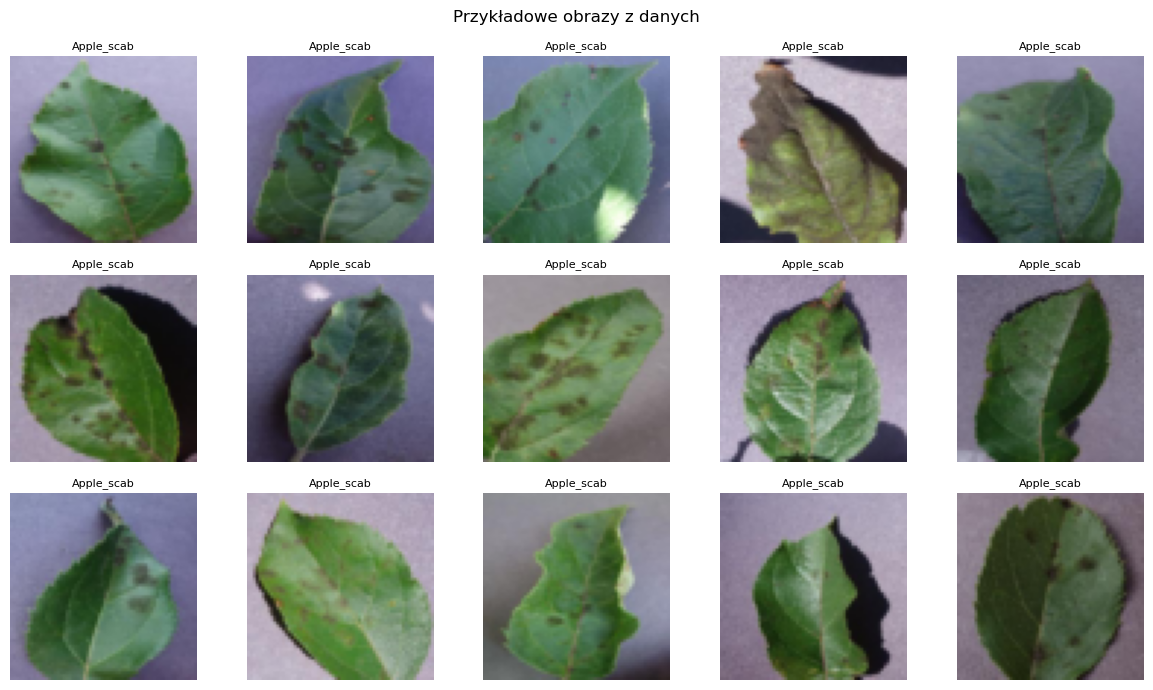

In [6]:
preview_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
preview_dataset = datasets.ImageFolder(DATA_ROOT, transform=preview_transform)

plt.figure(figsize=(12, 7))
for plot_i, dataset_i in enumerate(selected_indices[:15], start=1):
    image, label = preview_dataset[dataset_i]
    plt.subplot(3, 5, plot_i)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(all_classes[label].split("___")[-1], fontsize=8)
    plt.axis("off")
plt.suptitle("Przykładowe obrazy z danych")
plt.tight_layout()
plt.show()

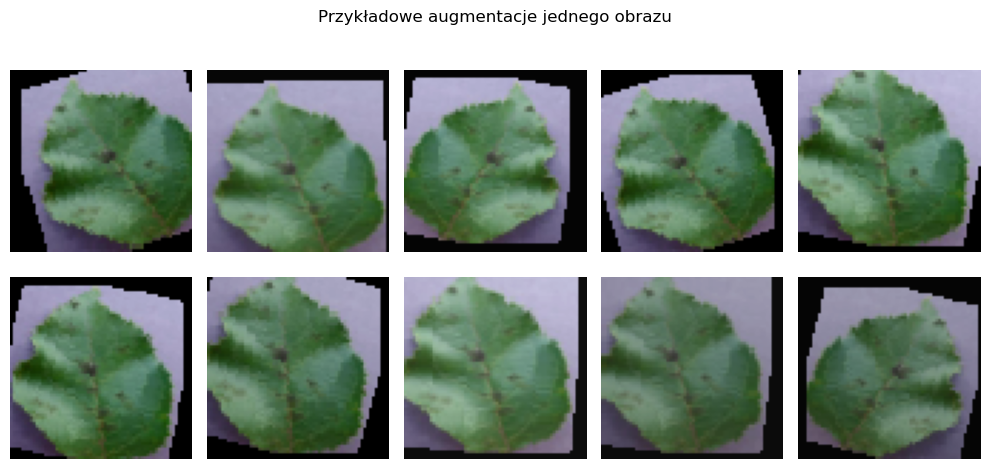

In [7]:
raw_image_path, _ = base_dataset.samples[selected_indices[0]]
raw_image = Image.open(raw_image_path).convert("RGB")

augmentation_preview = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.92, 1.08)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
])

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(augmentation_preview(raw_image))
    plt.axis("off")
plt.suptitle("Przykładowe augmentacje jednego obrazu")
plt.tight_layout()
plt.show()

## 5. Definicja MLP

In [8]:
def make_activation(name):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    if name == "gelu":
        return nn.GELU()
    if name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.1)
    raise ValueError(f"Nieznana funkcja aktywacji: {name}")


class MLP(nn.Module):
    def __init__(
        self,
        hidden1=512,
        hidden2=None,
        activation="relu",
        dropout=0.0,
        batchnorm=False,
        num_classes=NUM_CLASSES,
    ):
        super().__init__()
        input_size = 3 * IMG_SIZE * IMG_SIZE
        layers = [
            nn.Flatten(),
            nn.Linear(input_size, hidden1),
        ]
        if batchnorm:
            layers.append(nn.BatchNorm1d(hidden1))
        layers.append(make_activation(activation))
        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        if hidden2 is not None:
            layers.append(nn.Linear(hidden1, hidden2))
            if batchnorm:
                layers.append(nn.BatchNorm1d(hidden2))
            layers.append(make_activation(activation))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            layers.append(nn.Linear(hidden2, num_classes))
        else:
            layers.append(nn.Linear(hidden1, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

## 6. Trenowanie i ewaluacja

In [9]:
def make_optimizer(model, optimizer_name, lr, weight_decay):
    optimizer_name = optimizer_name.lower()
    if optimizer_name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "rmsprop":
        return torch.optim.RMSprop(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    raise ValueError(f"Nieznany optymalizator: {optimizer_name}")


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        if is_train:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)

    return running_loss / total, correct / total


def train_mlp(config, epochs=8, verbose=True):
    train_loader, val_loader, test_loader = make_loaders(
        batch_size=config["batch_size"],
        augment=config["augment"],
    )
    model = MLP(
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        activation=config["activation"],
        dropout=config["dropout"],
        batchnorm=config["batchnorm"],
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(
        model,
        optimizer_name=config["optimizer"],
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    best_state = None
    best_val_acc = -1
    history = []
    start = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())

        if verbose:
            print(f"Epoka {epoch:02d}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    model.load_state_dict(best_state)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)

    result = dict(config)
    result.update({
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "time_sec": time.time() - start,
    })

    return model, pd.DataFrame(history), result

## 7. Eksperyment bazowy

In [10]:
baseline_config = {
    "name": "baseline_1_hidden",
    "batch_size": 32,
    "optimizer": "adam",
    "lr": 1e-3,
    "hidden1": 512,
    "hidden2": None,
    "activation": "relu",
    "dropout": 0.0,
    "weight_decay": 0.0,
    "batchnorm": False,
    "augment": False,
}

baseline_model, baseline_history, baseline_result = train_mlp(baseline_config, epochs=8)
baseline_result

Epoka 01: train_acc=0.6635, val_acc=0.8329
Epoka 02: train_acc=0.8611, val_acc=0.8379
Epoka 03: train_acc=0.9151, val_acc=0.8404
Epoka 04: train_acc=0.9311, val_acc=0.8454
Epoka 05: train_acc=0.9530, val_acc=0.8753
Epoka 06: train_acc=0.9546, val_acc=0.8504
Epoka 07: train_acc=0.9567, val_acc=0.8678
Epoka 08: train_acc=0.9696, val_acc=0.8603


{'name': 'baseline_1_hidden',
 'batch_size': 32,
 'optimizer': 'adam',
 'lr': 0.001,
 'hidden1': 512,
 'hidden2': None,
 'activation': 'relu',
 'dropout': 0.0,
 'weight_decay': 0.0,
 'batchnorm': False,
 'augment': False,
 'best_val_acc': 0.8753117206982544,
 'test_loss': 0.4430018046231412,
 'test_acc': 0.8582089552238806,
 'time_sec': 126.27602529525757}

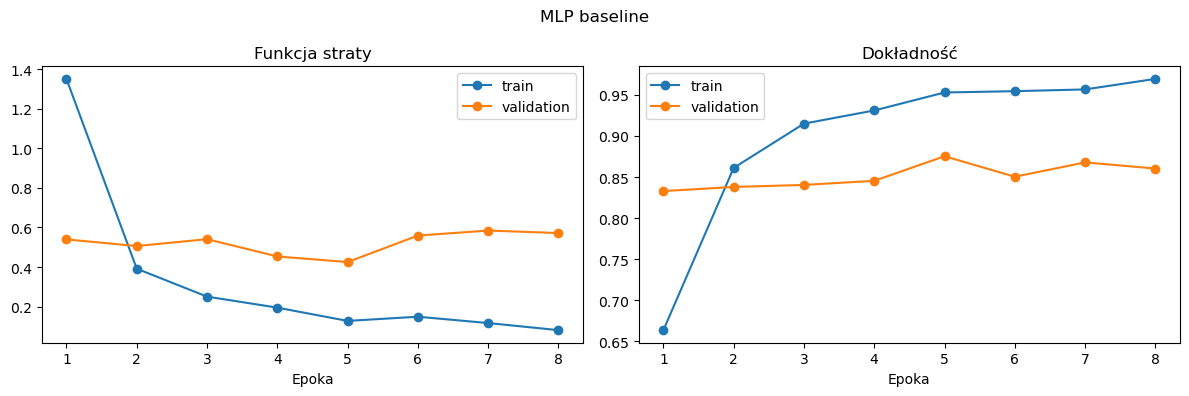

In [11]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
    axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="validation")
    axes[0].set_title("Funkcja straty")
    axes[0].set_xlabel("Epoka")
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_acc"], marker="o", label="train")
    axes[1].plot(history["epoch"], history["val_acc"], marker="o", label="validation")
    axes[1].set_title("Dokładność")
    axes[1].set_xlabel("Epoka")
    axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "MLP baseline")

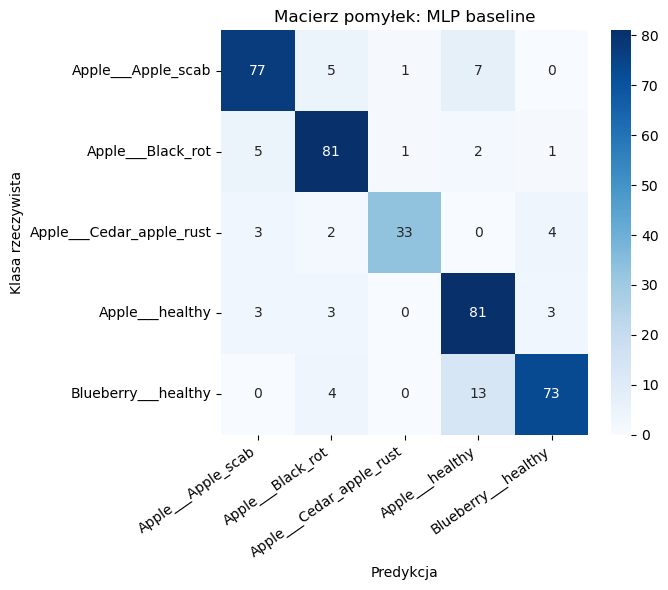

                          precision    recall  f1-score   support

      Apple___Apple_scab       0.88      0.86      0.87        90
       Apple___Black_rot       0.85      0.90      0.88        90
Apple___Cedar_apple_rust       0.94      0.79      0.86        42
         Apple___healthy       0.79      0.90      0.84        90
     Blueberry___healthy       0.90      0.81      0.85        90

                accuracy                           0.86       402
               macro avg       0.87      0.85      0.86       402
            weighted avg       0.86      0.86      0.86       402



In [12]:
def predict(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            y_pred.extend(logits.argmax(1).cpu().numpy())
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred)


_, _, test_loader = make_loaders(batch_size=64, augment=False)
y_true, y_pred = predict(baseline_model, test_loader)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Predykcja")
plt.ylabel("Klasa rzeczywista")
plt.title("Macierz pomyłek: MLP baseline")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=SELECTED_CLASSES))

## 8. Doświadczenia z hiperparametrami

In [13]:
experiments = [
    # Wielkość batcha
    {**baseline_config, "name": "batch_16", "batch_size": 16},
    {**baseline_config, "name": "batch_64", "batch_size": 64},

    # Optymalizator i długość kroku
    {**baseline_config, "name": "sgd_lr_1e-2", "optimizer": "sgd", "lr": 1e-2},
    {**baseline_config, "name": "adam_lr_1e-4", "optimizer": "adam", "lr": 1e-4},
    {**baseline_config, "name": "adamw_lr_1e-3", "optimizer": "adamw", "lr": 1e-3},
    {**baseline_config, "name": "rmsprop_lr_1e-3", "optimizer": "rmsprop", "lr": 1e-3},

    # Regularyzacja
    {**baseline_config, "name": "dropout_0_3", "dropout": 0.3},
    {**baseline_config, "name": "weight_decay_1e-4", "weight_decay": 1e-4},
    {**baseline_config, "name": "batchnorm", "batchnorm": True},
    {**baseline_config, "name": "dropout_weight_decay_aug", "dropout": 0.3, "weight_decay": 1e-4, "augment": True},

    # Druga warstwa ukryta
    {**baseline_config, "name": "two_hidden_512_256", "hidden2": 256},
    {**baseline_config, "name": "two_hidden_reg_aug", "hidden2": 256, "dropout": 0.3, "weight_decay": 1e-4, "augment": True},

    # Funkcje aktywacji
    {**baseline_config, "name": "activation_tanh", "activation": "tanh"},
    {**baseline_config, "name": "activation_gelu", "activation": "gelu"},
    {**baseline_config, "name": "activation_leaky_relu", "activation": "leaky_relu"},
]

all_results = [baseline_result]
histories = {"baseline_1_hidden": baseline_history}
models = {"baseline_1_hidden": baseline_model}

EPOCHS_PER_EXPERIMENT = 6

for config in experiments:
    print("\n==", config["name"], "==")
    model, history, result = train_mlp(config, epochs=EPOCHS_PER_EXPERIMENT, verbose=False)
    print(f"best_val_acc={result['best_val_acc']:.4f}, test_acc={result['test_acc']:.4f}")
    all_results.append(result)
    histories[config["name"]] = history
    models[config["name"]] = model

results_df = pd.DataFrame(all_results)
results_df.sort_values("test_acc", ascending=False)


== batch_16 ==
best_val_acc=0.8803, test_acc=0.8682

== batch_64 ==
best_val_acc=0.8853, test_acc=0.8955

== sgd_lr_1e-2 ==
best_val_acc=0.8753, test_acc=0.8756

== adam_lr_1e-4 ==
best_val_acc=0.8928, test_acc=0.9005

== adamw_lr_1e-3 ==
best_val_acc=0.8678, test_acc=0.8781

== rmsprop_lr_1e-3 ==
best_val_acc=0.7855, test_acc=0.7985

== dropout_0_3 ==
best_val_acc=0.8579, test_acc=0.8532

== weight_decay_1e-4 ==
best_val_acc=0.8678, test_acc=0.8383

== batchnorm ==
best_val_acc=0.9077, test_acc=0.9104

== dropout_weight_decay_aug ==
best_val_acc=0.8005, test_acc=0.7612

== two_hidden_512_256 ==
best_val_acc=0.8778, test_acc=0.8607

== two_hidden_reg_aug ==
best_val_acc=0.7082, test_acc=0.7313

== activation_tanh ==
best_val_acc=0.8603, test_acc=0.8483

== activation_gelu ==
best_val_acc=0.8728, test_acc=0.8806

== activation_leaky_relu ==
best_val_acc=0.8728, test_acc=0.8483


,name,batch_size,optimizer,lr,hidden1,hidden2,activation,dropout,weight_decay,batchnorm,augment,best_val_acc,test_loss,test_acc,time_sec
9,batchnorm,32,adam,0.0010,512,NaN,relu,0.0,0.0000,True,False,0.907731,0.255063,0.910448,73.362227
4,adam_lr_1e-4,32,adam,0.0001,512,NaN,relu,0.0,0.0000,False,False,0.892768,0.301269,0.900498,74.338665
2,batch_64,64,adam,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.885287,0.398075,0.895522,60.309969
14,activation_gelu,32,adam,0.0010,512,NaN,gelu,0.0,0.0000,False,False,0.872818,0.459317,0.880597,72.391384
5,adamw_lr_1e-3,32,adamw,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.867830,0.490591,0.878109,78.792442
3,sgd_lr_1e-2,32,sgd,0.0100,512,NaN,relu,0.0,0.0000,False,False,0.875312,0.417132,0.875622,58.216395
1,batch_16,16,adam,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.880299,0.522243,0.868159,125.180325
11,two_hidden_512_256,32,adam,0.0010,512,256.0,relu,0.0,0.0000,False,False,0.877805,0.430699,0.860697,74.605027
0,baseline_1_hidden,32,adam,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.875312,0.443002,0.858209,126.276025
7,dropout_0_3,32,adam,0.0010,512,NaN,relu,0.3,0.0000,False,False,0.857855,0.448439,0.853234,69.366104


## 9. Tabela końcowa i wizualizacja wyników

In [14]:
result_columns = [
    "name", "batch_size", "optimizer", "lr", "hidden1", "hidden2",
    "activation", "dropout", "weight_decay", "batchnorm", "augment",
    "best_val_acc", "test_acc", "test_loss", "time_sec",
]

final_table = results_df[result_columns].sort_values("test_acc", ascending=False).reset_index(drop=True)
final_table["best_val_acc"] = final_table["best_val_acc"].round(4)
final_table["test_acc"] = final_table["test_acc"].round(4)
final_table["test_loss"] = final_table["test_loss"].round(4)
final_table["time_sec"] = final_table["time_sec"].round(1)

final_table

,name,batch_size,optimizer,lr,hidden1,hidden2,activation,dropout,weight_decay,batchnorm,augment,best_val_acc,test_acc,test_loss,time_sec
0,batchnorm,32,adam,0.0010,512,NaN,relu,0.0,0.0000,True,False,0.9077,0.9104,0.2551,73.4
1,adam_lr_1e-4,32,adam,0.0001,512,NaN,relu,0.0,0.0000,False,False,0.8928,0.9005,0.3013,74.3
2,batch_64,64,adam,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.8853,0.8955,0.3981,60.3
3,activation_gelu,32,adam,0.0010,512,NaN,gelu,0.0,0.0000,False,False,0.8728,0.8806,0.4593,72.4
4,adamw_lr_1e-3,32,adamw,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.8678,0.8781,0.4906,78.8
5,sgd_lr_1e-2,32,sgd,0.0100,512,NaN,relu,0.0,0.0000,False,False,0.8753,0.8756,0.4171,58.2
6,batch_16,16,adam,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.8803,0.8682,0.5222,125.2
7,two_hidden_512_256,32,adam,0.0010,512,256.0,relu,0.0,0.0000,False,False,0.8778,0.8607,0.4307,74.6
8,baseline_1_hidden,32,adam,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.8753,0.8582,0.4430,126.3
9,dropout_0_3,32,adam,0.0010,512,NaN,relu,0.3,0.0000,False,False,0.8579,0.8532,0.4484,69.4


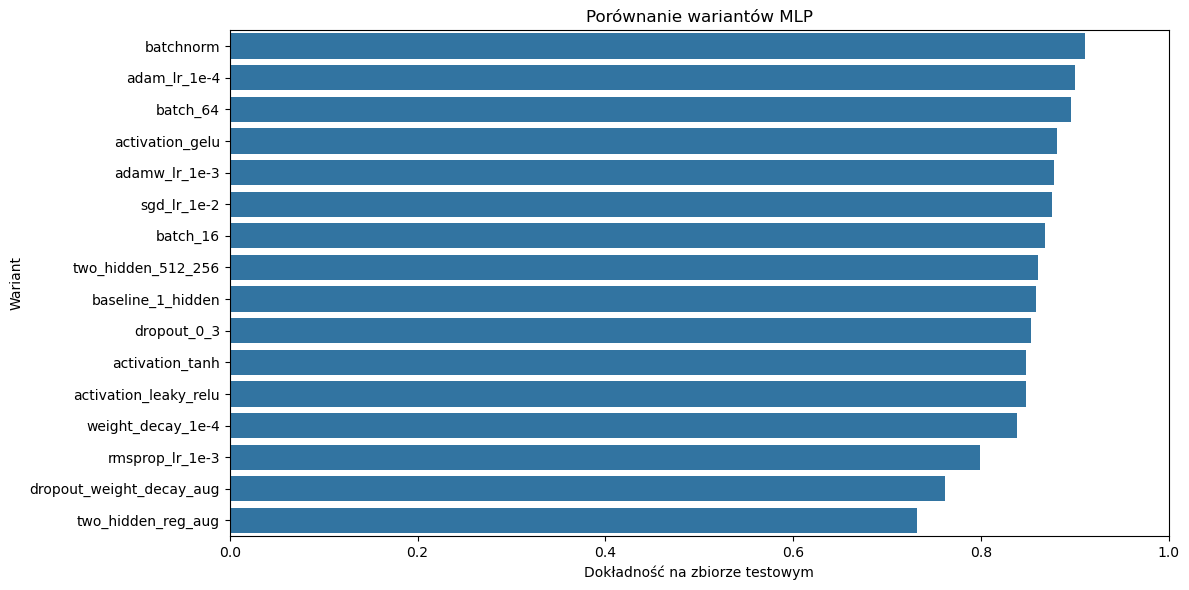

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(data=final_table, x="test_acc", y="name")
plt.xlim(0, 1)
plt.xlabel("Dokładność na zbiorze testowym")
plt.ylabel("Wariant")
plt.title("Porównanie wariantów MLP")
plt.tight_layout()
plt.show()

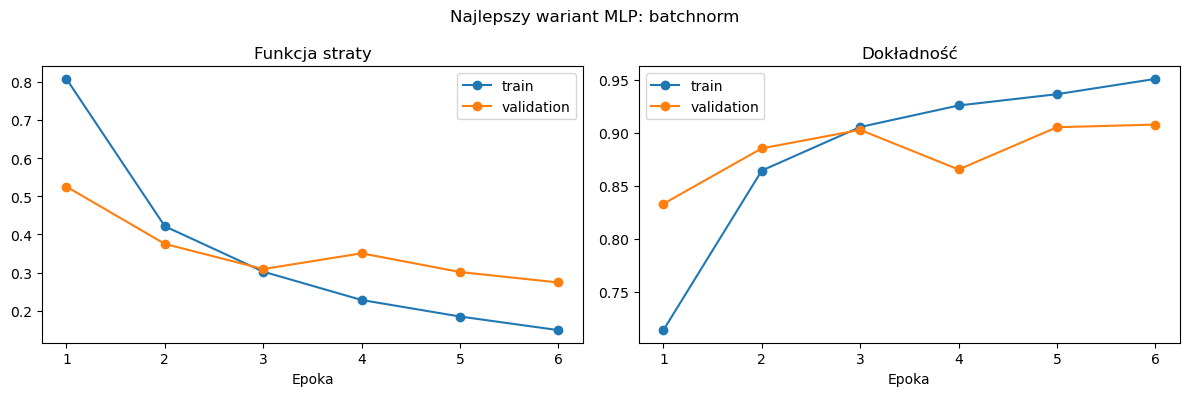

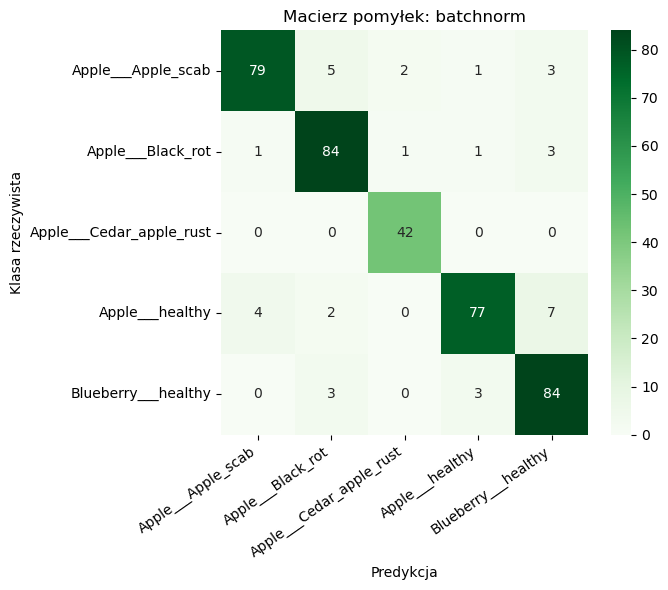

In [16]:
best_name = final_table.loc[0, "name"]
best_model = models[best_name]

plot_history(histories[best_name], f"Najlepszy wariant MLP: {best_name}")

_, _, test_loader = make_loaders(batch_size=64, augment=False)
y_true, y_pred = predict(best_model, test_loader)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Predykcja")
plt.ylabel("Klasa rzeczywista")
plt.title(f"Macierz pomyłek: {best_name}")
plt.tight_layout()
plt.show()

## 10. Dodatkowy CNN i wizualizacja filtrów splotowych

Epoka 01: train_acc=0.5214, val_acc=0.7456
Epoka 02: train_acc=0.7281, val_acc=0.8279
Epoka 03: train_acc=0.7804, val_acc=0.8354
Epoka 04: train_acc=0.8184, val_acc=0.8603
Epoka 05: train_acc=0.8435, val_acc=0.8903
Epoka 06: train_acc=0.8552, val_acc=0.9052
CNN test_acc=0.8980


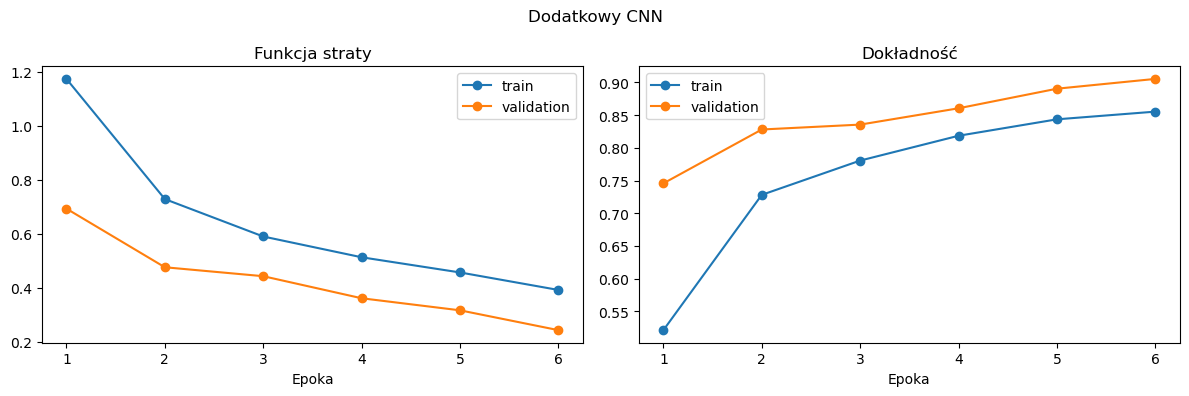

In [17]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (IMG_SIZE // 4) * (IMG_SIZE // 4), 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def train_cnn(epochs=6):
    train_loader, val_loader, test_loader = make_loaders(batch_size=32, augment=True)
    model = SmallCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    best_state = None
    best_val_acc = -1
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())
        print(f"Epoka {epoch:02d}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    model.load_state_dict(best_state)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)
    print(f"CNN test_acc={test_acc:.4f}")
    return model, pd.DataFrame(history), test_acc


cnn_model, cnn_history, cnn_test_acc = train_cnn(epochs=6)
plot_history(cnn_history, "Dodatkowy CNN")

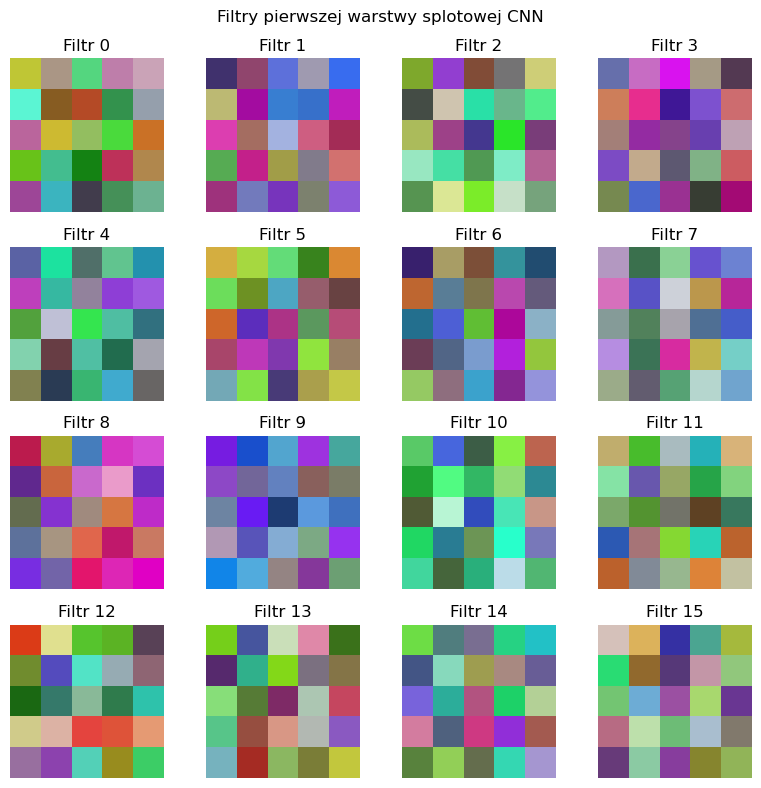

In [18]:
def visualize_first_conv_filters(model, max_filters=16):
    first_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            first_conv = module
            break

    if first_conv is None:
        raise ValueError("Model nie zawiera warstwy Conv2d.")

    filters = first_conv.weight.detach().cpu()
    filters = (filters - filters.min()) / (filters.max() - filters.min() + 1e-8)
    n_filters = min(max_filters, filters.shape[0])

    plt.figure(figsize=(8, 8))
    for i in range(n_filters):
        filt = filters[i].permute(1, 2, 0).numpy()
        plt.subplot(4, 4, i + 1)
        plt.imshow(filt)
        plt.title(f"Filtr {i}")
        plt.axis("off")

    plt.suptitle("Filtry pierwszej warstwy splotowej CNN")
    plt.tight_layout()
    plt.show()


visualize_first_conv_filters(cnn_model)

## 11. Zapis tabeli wyników

In [19]:
final_table.to_csv("wyniki_mlp_plantvillage.csv", index=False)
print("Zapisano: wyniki_mlp_plantvillage.csv")
final_table

Zapisano: wyniki_mlp_plantvillage.csv


,name,batch_size,optimizer,lr,hidden1,hidden2,activation,dropout,weight_decay,batchnorm,augment,best_val_acc,test_acc,test_loss,time_sec
0,batchnorm,32,adam,0.0010,512,NaN,relu,0.0,0.0000,True,False,0.9077,0.9104,0.2551,73.4
1,adam_lr_1e-4,32,adam,0.0001,512,NaN,relu,0.0,0.0000,False,False,0.8928,0.9005,0.3013,74.3
2,batch_64,64,adam,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.8853,0.8955,0.3981,60.3
3,activation_gelu,32,adam,0.0010,512,NaN,gelu,0.0,0.0000,False,False,0.8728,0.8806,0.4593,72.4
4,adamw_lr_1e-3,32,adamw,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.8678,0.8781,0.4906,78.8
5,sgd_lr_1e-2,32,sgd,0.0100,512,NaN,relu,0.0,0.0000,False,False,0.8753,0.8756,0.4171,58.2
6,batch_16,16,adam,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.8803,0.8682,0.5222,125.2
7,two_hidden_512_256,32,adam,0.0010,512,256.0,relu,0.0,0.0000,False,False,0.8778,0.8607,0.4307,74.6
8,baseline_1_hidden,32,adam,0.0010,512,NaN,relu,0.0,0.0000,False,False,0.8753,0.8582,0.4430,126.3
9,dropout_0_3,32,adam,0.0010,512,NaN,relu,0.3,0.0000,False,False,0.8579,0.8532,0.4484,69.4
